# Setup

All the Imports needed for this experiment.

In [1]:
from matplotlib import pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import gymnasium as gym
import numpy as np
import pandas as pd
import pickle
from datetime import datetime

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "blackjack_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from env.blackjack_env import BlackjackEnv
from agents.q_learning_agent import QLearningBlackjackAgent


Define default font size, plot colors etc.

In [2]:
def setup_plot_style():
    """Definiert das globale Design für alle Matplotlib-Plots."""
    # Schriftgrößen
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 11
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    
    # Linien & Grid
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['grid.alpha'] = 0.5
    
    # Layout & Render-Qualität
    plt.rcParams['figure.autolayout'] = True
    plt.rcParams['figure.dpi'] = 120
    
    # Optionale Farbpalette (z.B. "Tab10" oder "Set2" für modernen Look)
    plt.style.use('seaborn-v0_8-whitegrid') # Falls ein Grundtheme gewünscht ist

setup_plot_style()
AGENT_STYLES = {    
    "baseline": {"color": "#6b7c93", "label": "Baseline"},
    "counting":  {"color": "#2a9d8f", "label": "Counting"},
}


Create image folder for high-res images and image save function.

In [3]:
IMAGES_PATH = PROJECT_ROOT / "images"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    print(f"Figure saved: {path}")

# Environment & Agents

In [4]:
def baseline_state_key(obs) -> tuple[int, int, int]:
    player_total, dealer_upcard, usable_ace = obs[:3]

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace)
    )

def counting_state_key(obs: np.ndarray) -> tuple[int, int, int, int, int, int]:
    player_total, dealer_upcard, usable_ace, running_count, true_count, cards_remaining = obs
    count_bucket = int(np.clip(np.round(running_count), -20, 20))
    true_count_bucket = int(np.clip(np.round(true_count), -10, 10))
    shoe_bucket = int(np.clip(np.round(cards_remaining / 52.0), 0, 6))

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace),
        count_bucket,
        true_count_bucket,
        shoe_bucket,
    )


class BaselineBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=baseline_state_key,
            **kwargs,
        )
        
class CountingBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=counting_state_key,
            **kwargs,
        )


In [5]:
SEED = 42
N_EPISODES = 10_000_000

agent_config = {
    "learning_rate": 0.01,
    "initial_epsilon": 1.0,
    "final_epsilon": 0.1,
    "epsilon_decay": (1.0 - 0.1) / (N_EPISODES * 0.6),
}

def make_env(seed: int, n_episodes: int):
    env = BlackjackEnv(
        num_decks=6,
        penetration=0.75,
        stand_on_soft_17=True,
    )

    env = gym.wrappers.RecordEpisodeStatistics(
        env,
        buffer_length=n_episodes,
    )

    env.reset(seed=seed)
    env.action_space.seed(seed)

    return env

agents = {
    "baseline": BaselineBlackjackAgent(
        env=make_env(SEED, N_EPISODES),
        **agent_config,
    ),
    "counting": CountingBlackjackAgent(
        env=make_env(SEED, N_EPISODES),
        **agent_config,
    ),
}

# Training

In [6]:
# Trainieren der Agenten
for name, agent in agents.items():
    print(f"Starte Training für {name} Agent...")
    agent.train(n_episodes=N_EPISODES, base_seed=SEED)
    print(f"Training für {name} Agent erfolgreich beendet.\n")

Starte Training für baseline Agent...


Training für baseline Agent erfolgreich beendet.

Starte Training für counting Agent...


Training für counting Agent erfolgreich beendet.



# Saving

In [7]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for name, agent in agents.items():
    print(f"Saving {name} agent...")
    
    filename = f"{name}_agent_{timestamp}.pkl"
    path = MODEL_DIR / filename
    
    agent.save(path, label=f"{name}_{timestamp}")
    print(f"-> Erfolgreich gespeichert unter: {path}")

Saving baseline agent...
-> Erfolgreich gespeichert unter: E:\tomni\Documents\01_Code\ml-blackjack\models\baseline_agent_20260603_142944.pkl
Saving counting agent...
-> Erfolgreich gespeichert unter: E:\tomni\Documents\01_Code\ml-blackjack\models\counting_agent_20260603_142944.pkl


# Evaluation

## Training Dynamics

In [8]:
def get_moving_stats(arr, window: int):
    arr = np.asarray(arr).flatten()
    if len(arr) == 0:
        return arr, arr, np.arange(0)

    min_periods = max(1, window // 10)
    series = pd.Series(arr)

    means = series.rolling(window=window, min_periods=min_periods).mean().to_numpy()
    stds = series.rolling(window=window, min_periods=min_periods).std().to_numpy()
    stds = np.nan_to_num(stds)

    return means, stds, np.arange(len(arr))

def plot_all(agents: dict, reward_window: int = 1000, td_window: int = 5000):

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    for name, agent in agents.items():
        style = AGENT_STYLES[name]
        # Links: Rewards
        rewards = np.asarray(agent.episode_rewards)
        r_means, _, x_r = get_moving_stats(rewards, reward_window)
        axs[0].plot(x_r, r_means, label=style["label"], color=style["color"], linewidth=2.5)

        # Rechts: TD Error
        td_errors = np.asarray(agent.training_error)
        t_means, _, x_t = get_moving_stats(td_errors, td_window)
        axs[1].plot(x_t, t_means, label=style["label"], color=style["color"], linewidth=2.5)

    axs[0].set_title("Episode Rewards (Geglättet)")
    axs[0].set_xlabel("Episode")
    axs[0].set_ylabel("Reward")
    axs[0].legend()

    axs[1].set_title("TD Error Verlauf")
    axs[1].set_xlabel("Step")
    axs[1].set_ylabel("TD Error")
    axs[1].legend()

    save_fig("training_results_combined")
    plt.show()

C:\Users\tomni\AppData\Local\Temp\ipykernel_7948\3655274183.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\tomni\AppData\Local\Temp\ipykernel_7948\3655274183.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(path, format=fig_extension, dpi=resolution)


Figure saved: E:\tomni\Documents\01_Code\ml-blackjack\images\training_results_combined.png


c:\Users\tomni\miniconda3\envs\ml-blackjack\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


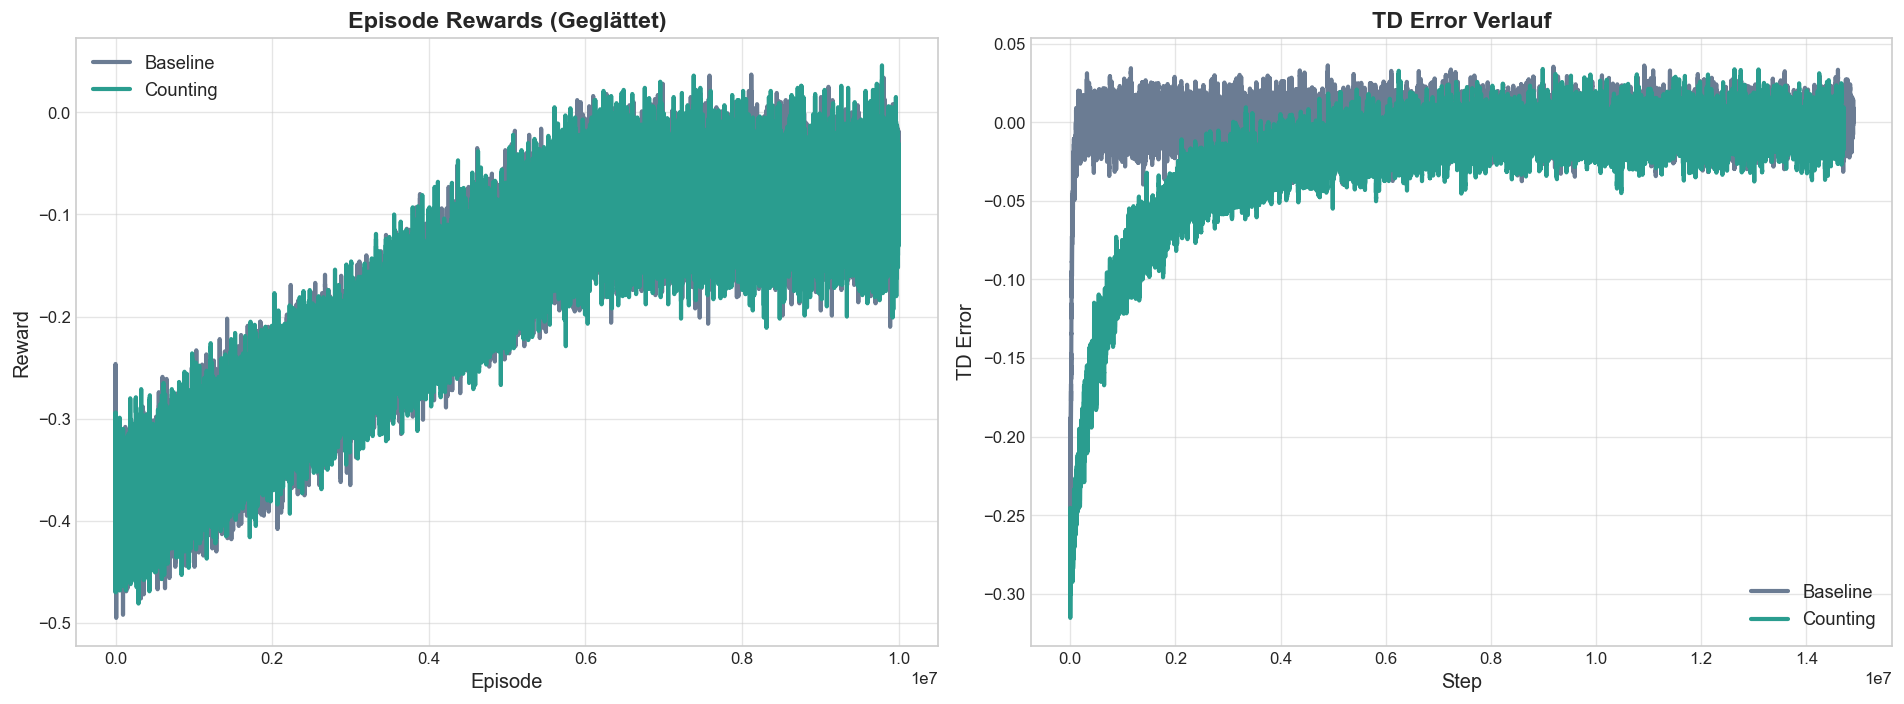

In [9]:
plot_all(agents, reward_window=1000, td_window=5000)

## Performance Comparison

In [10]:
print("Starte finale Evaluierung der Agenten...\n")

# Extrahiere die Kurven direkt aus unseren trainierten Agenten-Objekten
baseline_rewards = agents["baseline"].episode_rewards
counting_rewards = agents["counting"].episode_rewards

baseline_error_curve = agents["baseline"].training_error
counting_error_curve = agents["counting"].training_error

# Berechne Metriken basierend auf den letzten 10.000 Episoden (Evaluations-Fenster)
EVAL_WINDOW = 10_000

def calculate_metrics(rewards_list: list, eval_window: int = EVAL_WINDOW) -> dict:
    """
    Berechnet Win Rate, Average Reward und Std aus den letzten `eval_window` Episoden.

    Args:
        rewards_list: Liste der Episoden-Rewards des Agenten.
        eval_window:  Anzahl der letzten Episoden für die Auswertung.

    Returns:
        Dict mit win_rate, average_reward, std_reward.
    """
    eval_rewards = np.array(rewards_list[-eval_window:])
    wins = np.sum(eval_rewards > 0)
    total = len(eval_rewards)

    return {
        "win_rate":       wins / total if total > 0 else 0.0,
        "average_reward": np.mean(eval_rewards),
        "std_reward":     np.std(eval_rewards),
    }

baseline_metrics = calculate_metrics(baseline_rewards)
counting_metrics  = calculate_metrics(counting_rewards)

# Metriken ausgeben
for name, metrics in [("Baseline", baseline_metrics), ("Counting", counting_metrics)]:
    print(f"{name} metrics:")
    print(f"  Win Rate:           {metrics['win_rate']:.1%}")
    print(f"  Average Reward:     {metrics['average_reward']:.3f}")
    print(f"  Standard Deviation: {metrics['std_reward']:.3f}")
    print()

Starte finale Evaluierung der Agenten...

Baseline metrics:
  Win Rate:           41.7%
  Average Reward:     -0.077
  Standard Deviation: 0.952

Counting metrics:
  Win Rate:           41.4%
  Average Reward:     -0.086
  Standard Deviation: 0.952



C:\Users\tomni\AppData\Local\Temp\ipykernel_7948\3655274183.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\tomni\AppData\Local\Temp\ipykernel_7948\3655274183.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(path, format=fig_extension, dpi=resolution)


Figure saved: E:\tomni\Documents\01_Code\ml-blackjack\images\final_evaluation_metrics.png


c:\Users\tomni\miniconda3\envs\ml-blackjack\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


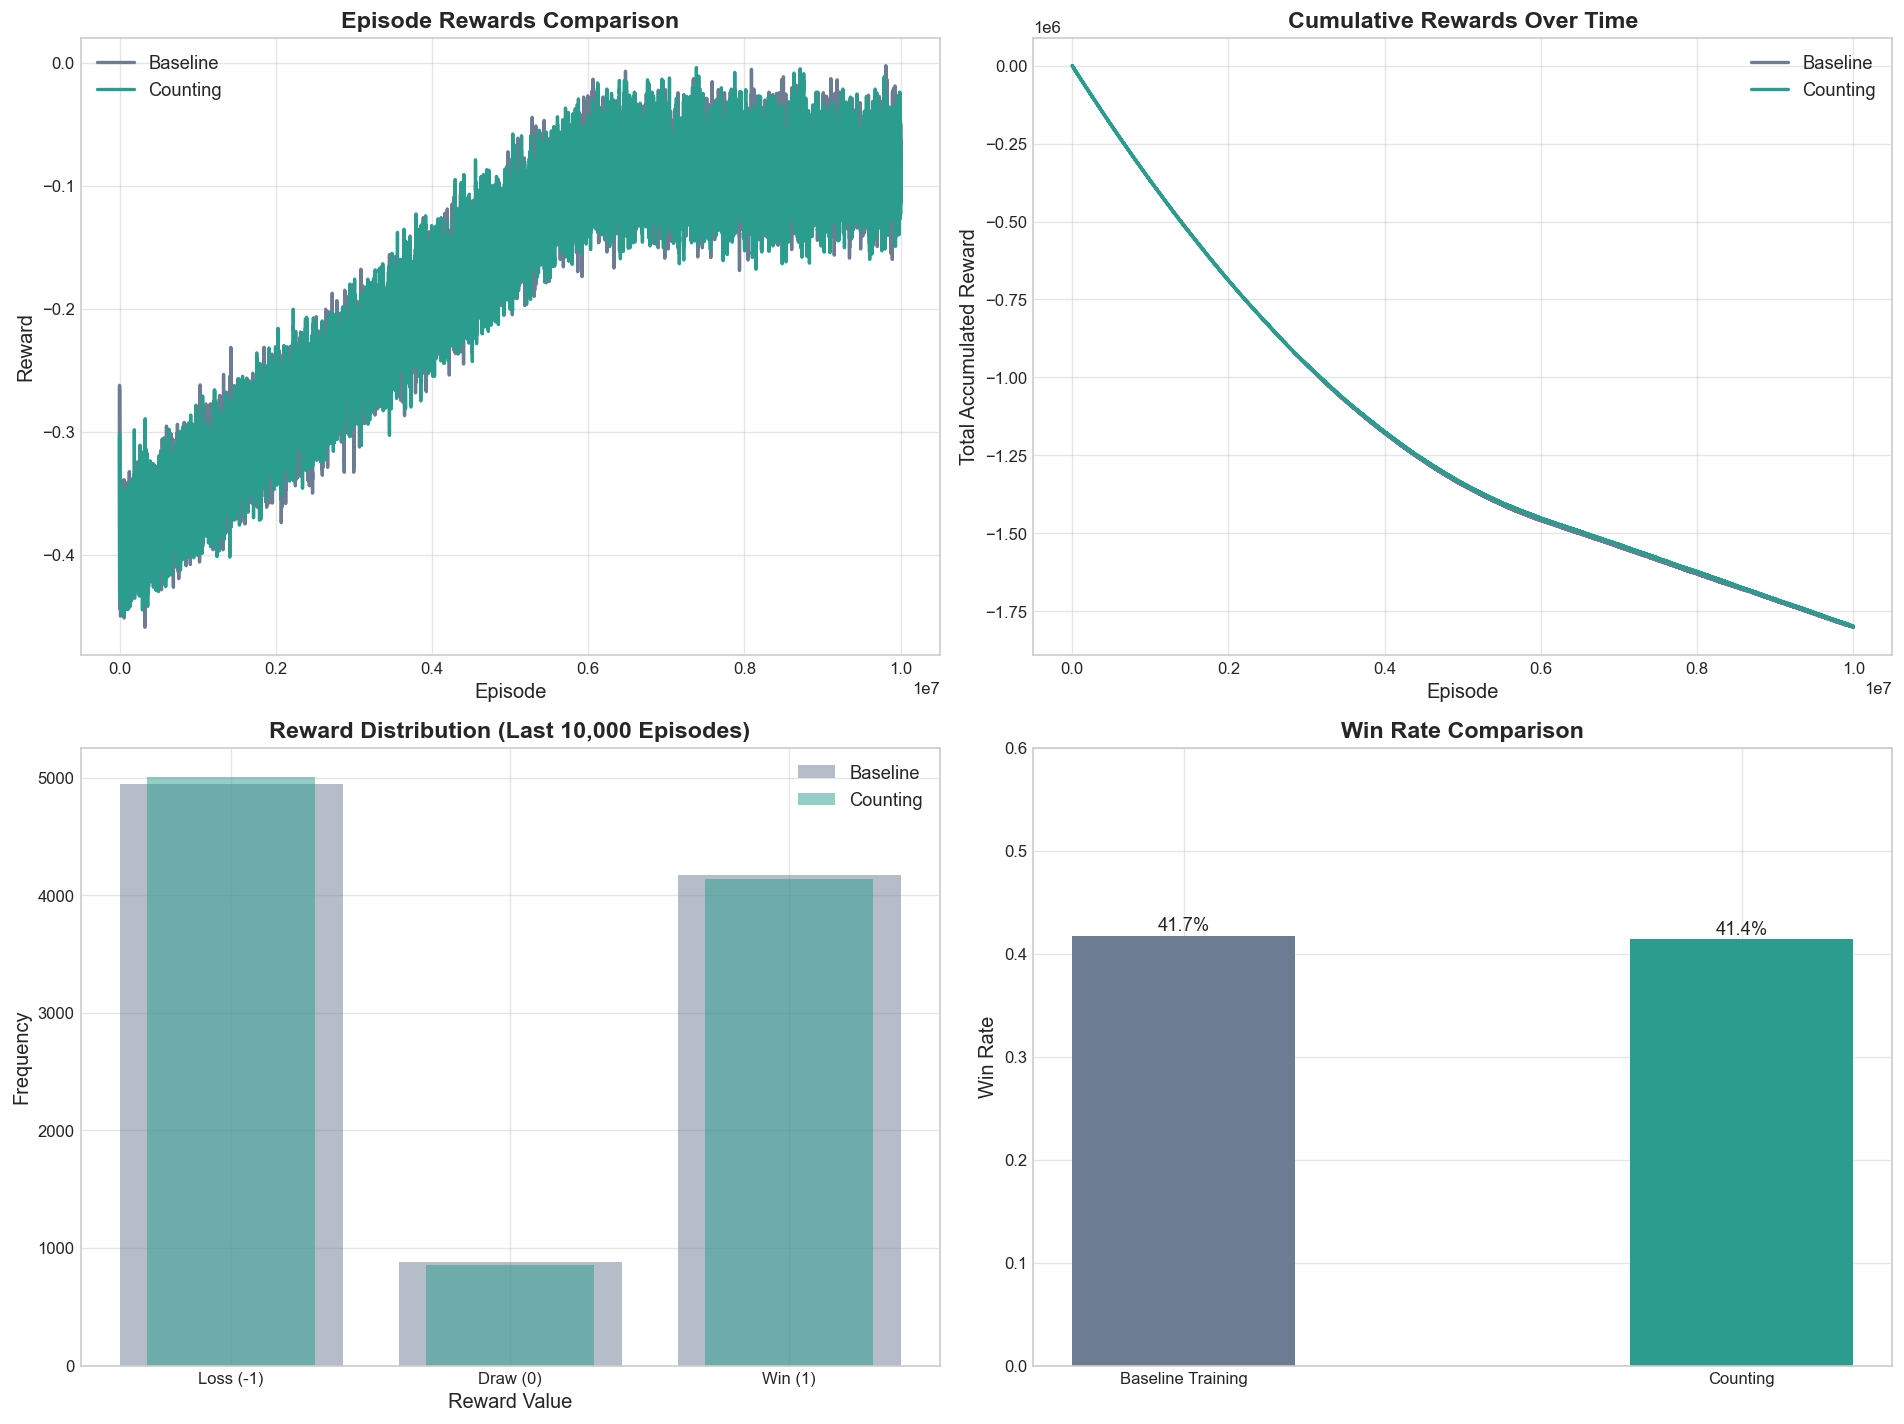

In [11]:
# Fenstergröße für die statistische Glättung
SMOOTH_WINDOW = 2_000

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Top-Left: Geglätteter Reward-Vergleich
r_mean_b, _, x_r_b = get_moving_stats(baseline_rewards, SMOOTH_WINDOW)
r_mean_c, _, x_r_c = get_moving_stats(counting_rewards, SMOOTH_WINDOW)
axs[0, 0].plot(x_r_b, r_mean_b, label="Baseline", color="#6b7c93")
axs[0, 0].plot(x_r_c, r_mean_c, label="Counting",  color="#2a9d8f")
axs[0, 0].set_title("Episode Rewards Comparison")
axs[0, 0].set_xlabel("Episode")
axs[0, 0].set_ylabel("Reward")
axs[0, 0].legend()

# Top-Right: Kumulativer Reward
axs[0, 1].plot(np.cumsum(baseline_rewards), label="Baseline", color="#6b7c93")
axs[0, 1].plot(np.cumsum(counting_rewards),  label="Counting",  color="#2a9d8f")
axs[0, 1].set_title("Cumulative Rewards Over Time")
axs[0, 1].set_xlabel("Episode")
axs[0, 1].set_ylabel("Total Accumulated Reward")
axs[0, 1].legend()

# Bottom-Left: Reward-Verteilung (Histogramm der letzten EVAL_WINDOW Episoden)
bins = [-1.5, -0.5, 0.5, 1.5]
axs[1, 0].hist(baseline_rewards[-EVAL_WINDOW:], alpha=0.5, label="Baseline", color="#6b7c93", bins=bins, rwidth=0.8)
axs[1, 0].hist(counting_rewards[-EVAL_WINDOW:],  alpha=0.5, label="Counting",  color="#2a9d8f", bins=bins, rwidth=0.6)
axs[1, 0].set_title(f"Reward Distribution (Last {EVAL_WINDOW:,} Episodes)")
axs[1, 0].set_xlabel("Reward Value")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].set_xticks([-1, 0, 1])
axs[1, 0].set_xticklabels(["Loss (-1)", "Draw (0)", "Win (1)"])
axs[1, 0].legend()

# Bottom-Right: Win Rate Vergleich (Balken)
names = ["Baseline Training", "Counting"]
win_rates = [baseline_metrics["win_rate"], counting_metrics["win_rate"]]
axs[1, 1].bar(names, win_rates, color=["#6b7c93", "#2a9d8f"], width=0.4)
axs[1, 1].set_title("Win Rate Comparison")
axs[1, 1].set_ylabel("Win Rate")
axs[1, 1].set_ylim(0, 0.6)
for i, v in enumerate(win_rates):
    axs[1, 1].text(i, v + 0.005, f"{v:.1%}", ha="center")

save_fig("final_evaluation_metrics")
plt.show()